# YouTube Trending Video Statistics — India
## Exploratory Data Analysis

This notebook documents a reproducible EDA workflow for the India dataset (`INvideos.csv`). The analysis is descriptive: relationships are reported as associations and are not treated as causal effects.

## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'INvideos.csv'
CAT = ROOT / 'data' / 'IN_category_id.json'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
print('Shape:', df.shape)
df.head()

Shape: (37352, 16)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


## 2. Initial inspection

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37352 non-null  object
 1   trending_date           37352 non-null  object
 2   title                   37352 non-null  object
 3   channel_title           37352 non-null  object
 4   category_id             37352 non-null  int64 
 5   publish_time            37352 non-null  object
 6   tags                    37352 non-null  object
 7   views                   37352 non-null  int64 
 8   likes                   37352 non-null  int64 
 9   dislikes                37352 non-null  int64 
 10  comment_count           37352 non-null  int64 
 11  thumbnail_link          37352 non-null  object
 12  comments_disabled       37352 non-null  bool  
 13  ratings_disabled        37352 non-null  bool  
 14  video_error_or_removed  37352 non-null  bool  
 15  de

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,37352,16307,#NAME?,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,37352,205,17.14.11,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,37352,16721,Mission: Impossible - Fallout (2018) - Officia...,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,37352,1426,VikatanTV,284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,37352.0,NaN,NaN,NaN,21.576596,6.556593,1.0,23.0,24.0,24.0,43.0
publish_time,37352,16339,2018-04-21T13:30:01.000Z,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,37352,12578,[none],1381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,37352.0,NaN,NaN,NaN,1060477.645882,3184932.053381,4024.0,123915.5,304586.0,799291.25,125432237.0
likes,37352.0,NaN,NaN,NaN,27082.717659,97145.095131,0.0,864.0,3069.0,13774.25,2912710.0
dislikes,37352.0,NaN,NaN,NaN,1665.081977,16076.174539,0.0,108.0,326.0,1019.25,1545017.0


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])
print('Exact duplicate rows:', df.duplicated().sum())

description    561
dtype: int64
Exact duplicate rows: 4263


### Initial observations
The India file contains 37,352 rows and 16 columns. The initial missing-value check identifies 561 missing values in `description`. There are 4,263 exact duplicate rows. Duplicate handling is performed explicitly below rather than silently dropping rows.

## 3. Data cleaning and preprocessing

In [5]:
analysis = df.drop_duplicates().copy()
analysis['trending_date_parsed'] = pd.to_datetime(analysis['trending_date'], format='%y.%d.%m', errors='coerce')
analysis['publish_datetime'] = pd.to_datetime(analysis['publish_time'], errors='coerce', utc=True)

with open(CAT, encoding='utf-8') as f:
    categories = json.load(f)
cat_map = {int(x['id']): x['snippet']['title'] for x in categories['items']}
analysis['category_name'] = analysis['category_id'].map(cat_map).fillna(analysis['category_id'].astype(str))

print('Before:', df.shape)
print('After exact-duplicate removal:', analysis.shape)
print('Parsed trending dates:', analysis['trending_date_parsed'].notna().sum())
print('Parsed publish timestamps:', analysis['publish_datetime'].notna().sum())

Before: (37352, 16)
After exact-duplicate removal: (33089, 19)
Parsed trending dates: 33089
Parsed publish timestamps: 33089


In [6]:
analysis.isna().sum().sort_values(ascending=False).head(10)

description      527
trending_date      0
video_id           0
title              0
channel_title      0
publish_time       0
category_id        0
views              0
likes              0
dislikes           0
dtype: int64

## 4. Quantitative analysis

In [7]:
engagement = ['views','likes','dislikes','comment_count']
analysis[engagement].describe().T

,count,mean,std,min,25%,50%,75%,max
views,33089.0,996342.506573,3.148111e+06,4024.0,112719.0,275027.0,732022.0,125432237.0
likes,33089.0,25587.621052,9.647320e+04,0.0,787.0,2757.0,12011.0,2912710.0
dislikes,33089.0,1576.535012,1.689573e+04,0.0,98.0,289.0,932.0,1545017.0
comment_count,33089.0,2524.777660,1.476983e+04,0.0,72.0,298.0,1169.0,827755.0


In [8]:
corr = analysis[engagement].corr()
corr

,views,likes,dislikes,comment_count
views,1.000000,0.852704,0.551652,0.697749
likes,0.852704,1.000000,0.499926,0.792815
dislikes,0.551652,0.499926,1.000000,0.740269
comment_count,0.697749,0.792815,0.740269,1.000000


## 5. Univariate analysis

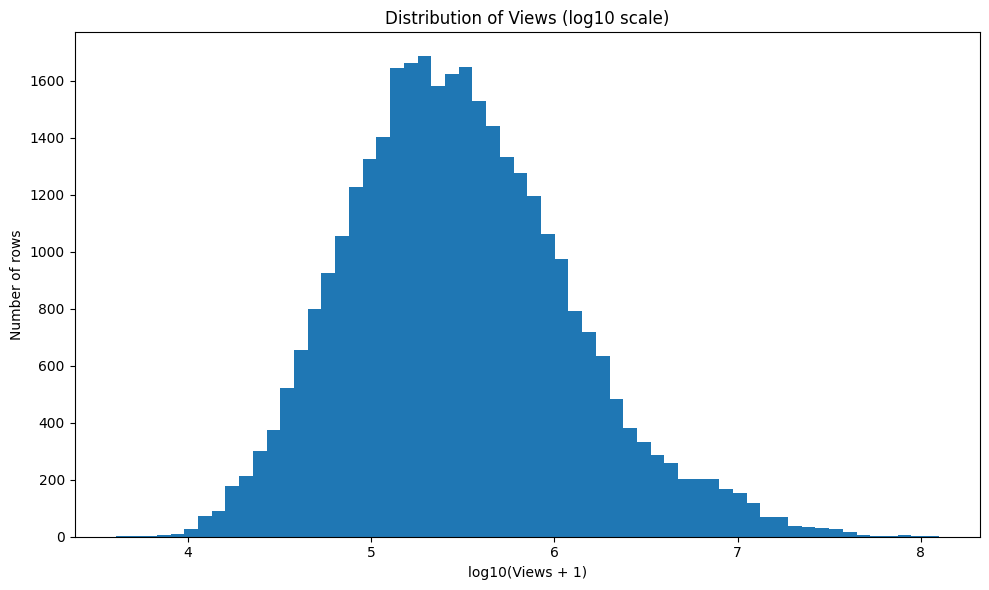

In [9]:
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(np.log10(analysis['views'] + 1), bins=60)
ax.set_title('Distribution of Views (log10 scale)')
ax.set_xlabel('log10(Views + 1)')
ax.set_ylabel('Number of rows')
plt.tight_layout()
plt.show()

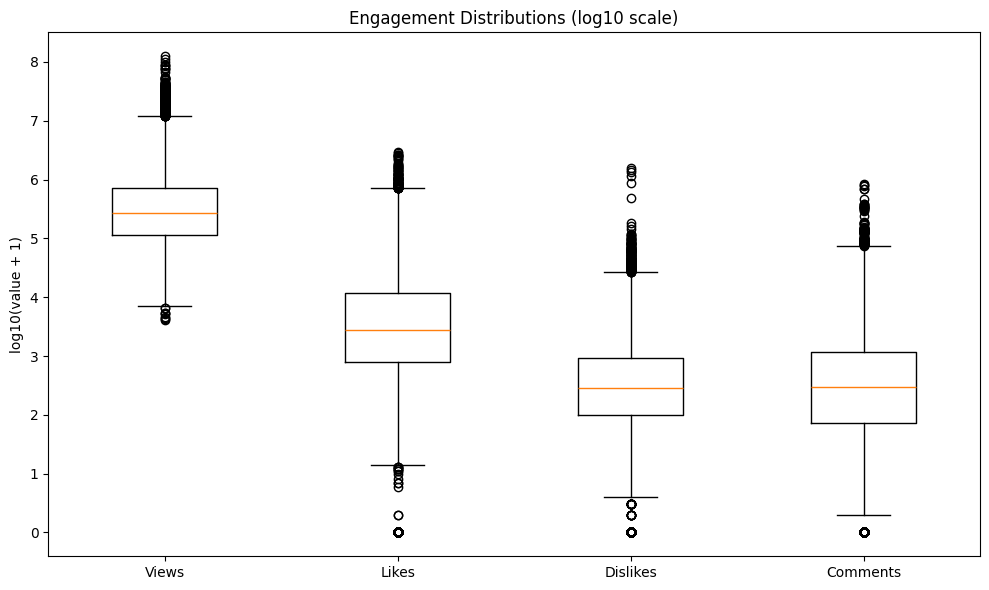

In [10]:
fig, ax = plt.subplots(figsize=(10,6))
values = [np.log10(analysis[c] + 1) for c in engagement]
ax.boxplot(values, tick_labels=['Views','Likes','Dislikes','Comments'])
ax.set_title('Engagement Distributions (log10 scale)')
ax.set_ylabel('log10(value + 1)')
plt.tight_layout()
plt.show()

## 6. Category analysis

In [11]:
category_summary = (analysis.groupby('category_name')
    .agg(videos=('video_id','count'), median_views=('views','median'),
         median_likes=('likes','median'), median_comments=('comment_count','median'))
    .sort_values('videos', ascending=False))
category_summary.head(15)

,videos,median_views,median_likes,median_comments
category_name,,,,
Entertainment,14764,250234.0,1802.0,195.0
News & Politics,4709,174239.0,1066.0,154.0
Music,3292,825655.0,15924.5,948.0
Comedy,2967,448912.0,17668.0,1354.0
People & Blogs,2367,234387.0,1402.0,154.0
Film & Animation,1463,657768.0,7716.0,557.0
Education,1166,50872.0,2448.5,269.5
Howto & Style,801,245371.0,3123.0,408.0
Sports,646,655190.0,6075.0,559.0


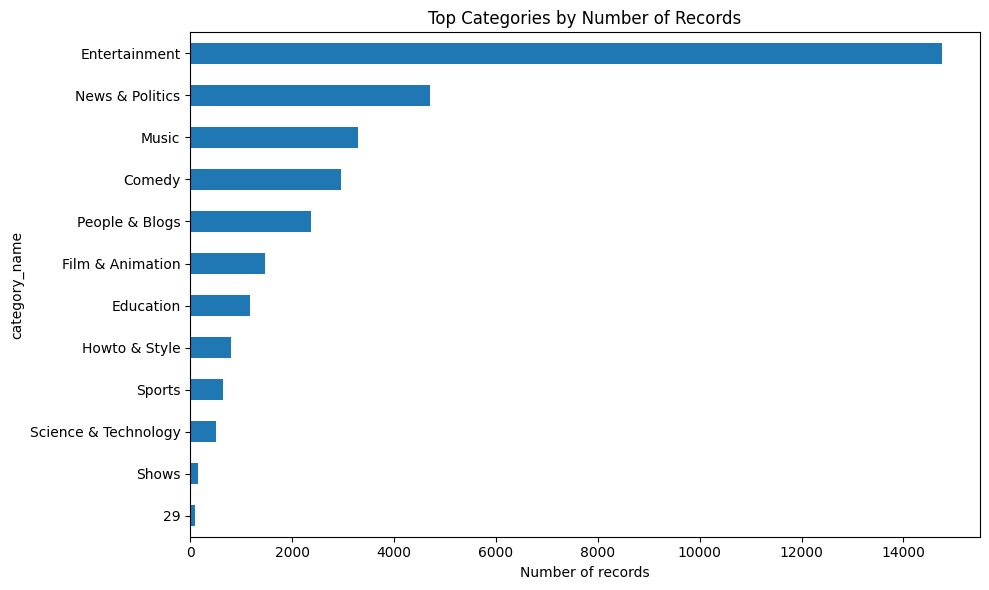

In [12]:
fig, ax = plt.subplots(figsize=(10,6))
s = category_summary.head(12).sort_values('videos')
s['videos'].plot(kind='barh', ax=ax)
ax.set_title('Top Categories by Number of Records')
ax.set_xlabel('Number of records')
plt.tight_layout()
plt.show()

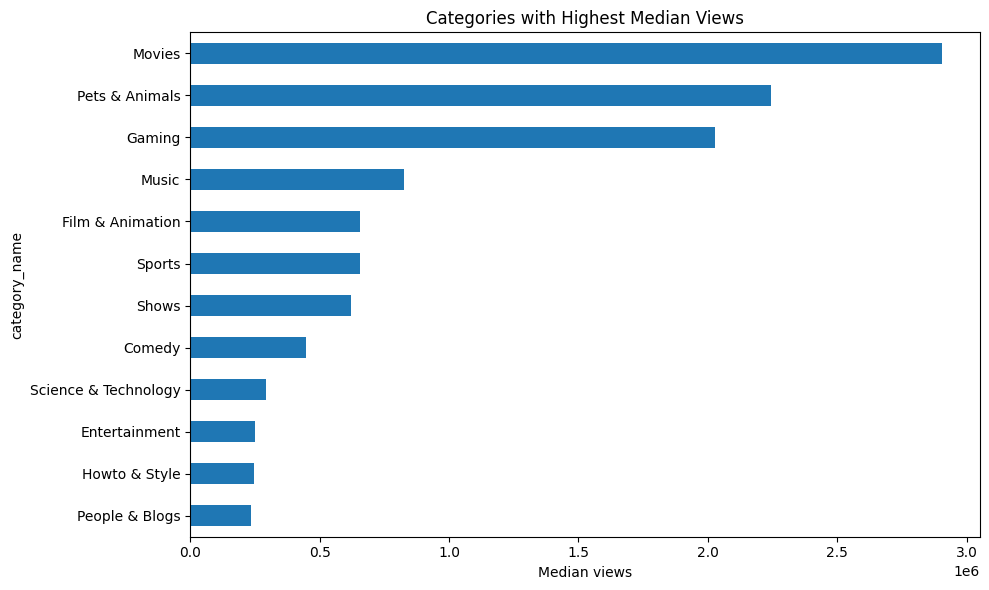

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
s = category_summary.sort_values('median_views').tail(12)
s['median_views'].plot(kind='barh', ax=ax)
ax.set_title('Categories with Highest Median Views')
ax.set_xlabel('Median views')
plt.tight_layout()
plt.show()

## 7. Relationship analysis

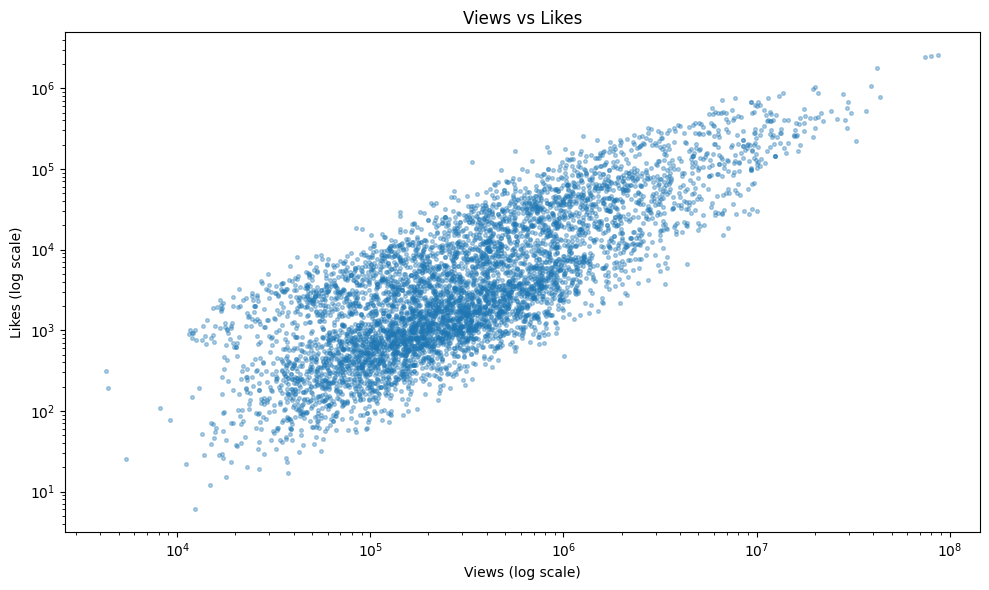

In [14]:
sample = analysis.sample(min(6000, len(analysis)), random_state=42)
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(sample['views'], sample['likes'], s=7, alpha=0.35)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Views vs Likes')
ax.set_xlabel('Views (log scale)'); ax.set_ylabel('Likes (log scale)')
plt.tight_layout(); plt.show()

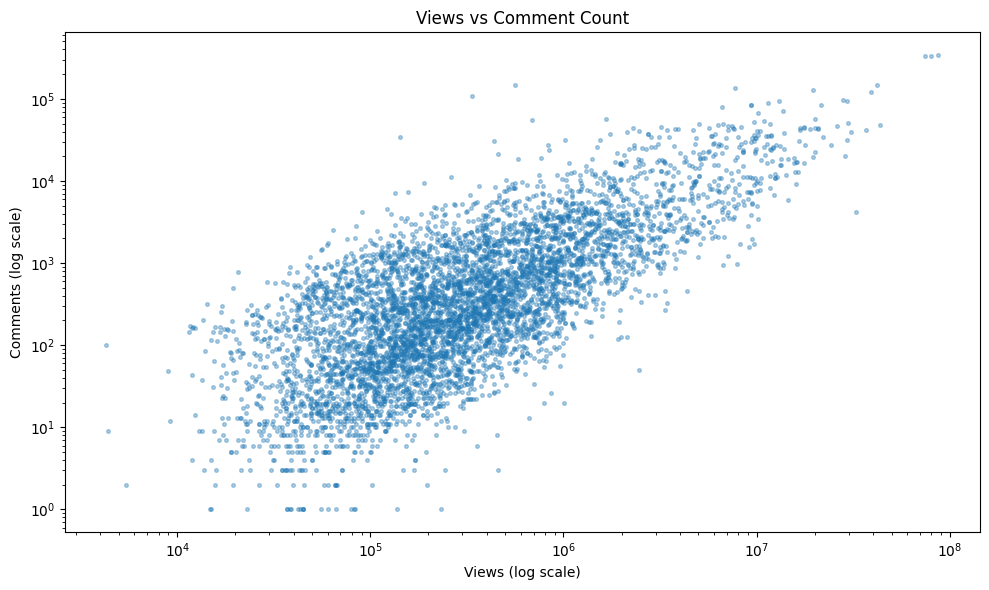

In [15]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(sample['views'], sample['comment_count'], s=7, alpha=0.35)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Views vs Comment Count')
ax.set_xlabel('Views (log scale)'); ax.set_ylabel('Comments (log scale)')
plt.tight_layout(); plt.show()

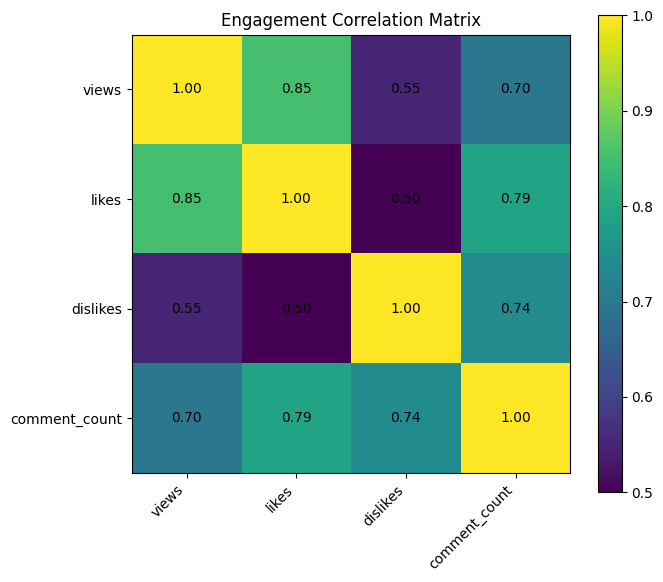

In [16]:
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr.values)
ax.set_xticks(range(4), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(4), corr.index)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center')
ax.set_title('Engagement Correlation Matrix')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 8. Temporal analysis

In [17]:
daily = (analysis.groupby('trending_date_parsed')
         .agg(videos=('video_id','count'), median_views=('views','median'))
         .sort_index())
daily.head()

,videos,median_views
trending_date_parsed,,
2017-11-14,200,117622.5
2017-11-15,200,151069.0
2017-11-16,200,168675.5
2017-11-17,200,169136.0
2017-11-18,200,186669.5


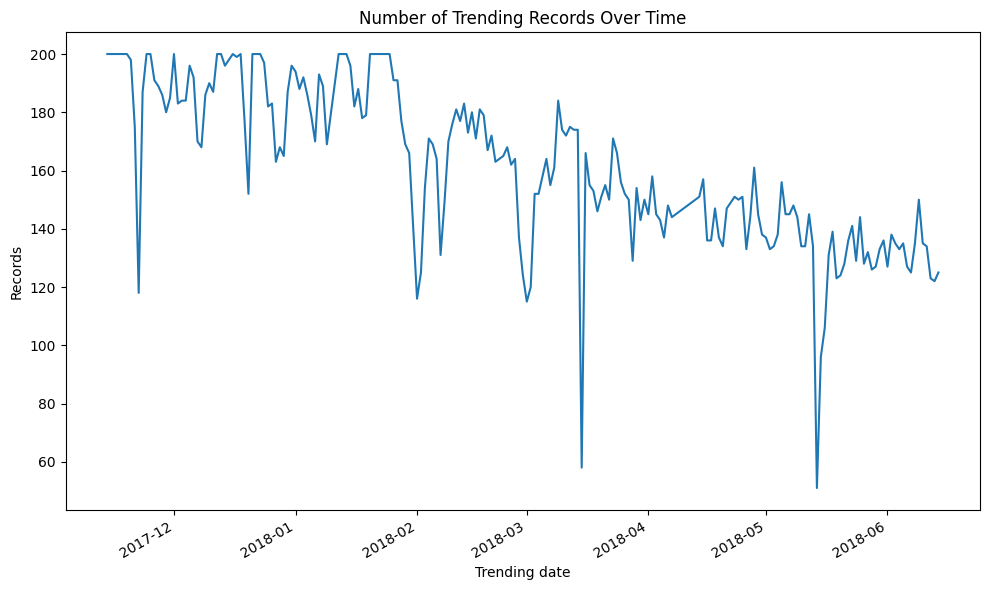

In [18]:
fig, ax = plt.subplots(figsize=(10,6))
daily['videos'].plot(ax=ax)
ax.set_title('Number of Trending Records Over Time')
ax.set_xlabel('Trending date'); ax.set_ylabel('Records')
plt.tight_layout(); plt.show()

## 9. Channel analysis

In [19]:
channel_summary = (analysis.groupby('channel_title')
    .agg(videos=('video_id','count'), median_views=('views','median'), total_views=('views','sum'))
    .sort_values('videos', ascending=False))
channel_summary.head(15)

,videos,median_views,total_views
channel_title,,,
VikatanTV,208,665398.0,151026885
SAB TV,206,276507.0,80287318
ETV Plus India,206,320455.5,95562261
etvteluguindia,205,209475.0,89450329
Study IQ education,202,52044.5,11422244
Flowers Comedy,202,592998.5,134339392
Tarang TV,199,85591.0,20019000
SET India,199,649790.0,191136460
Mazhavil Manorama,196,255161.0,62898862


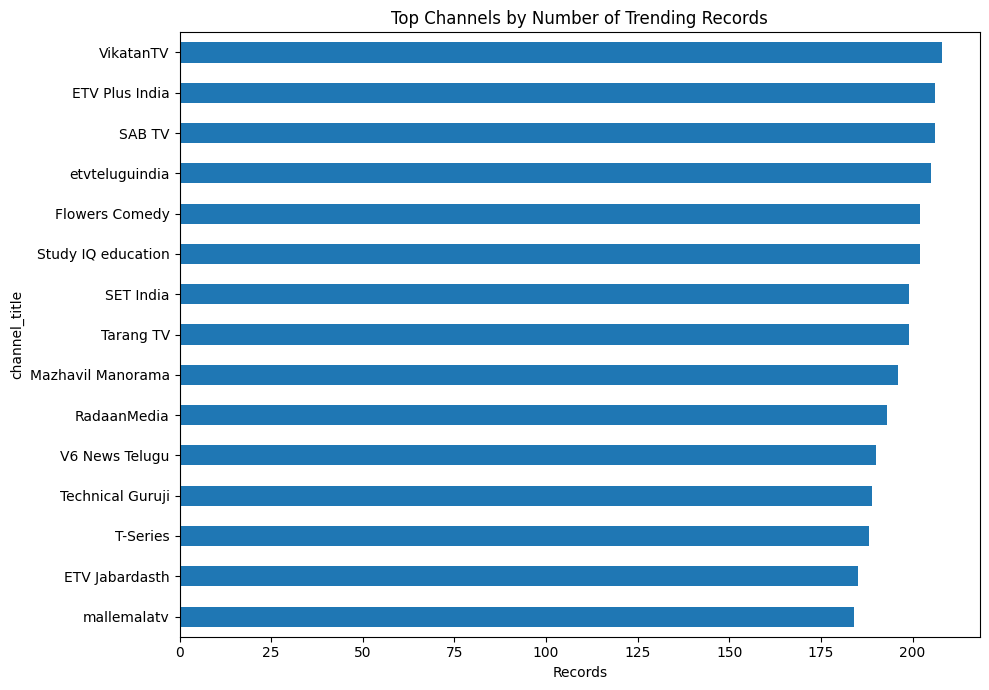

In [20]:
fig, ax = plt.subplots(figsize=(10,7))
s = channel_summary.head(15).sort_values('videos')
s['videos'].plot(kind='barh', ax=ax)
ax.set_title('Top Channels by Number of Trending Records')
ax.set_xlabel('Records')
plt.tight_layout(); plt.show()

## 10. Evidence-based findings

In [21]:
findings = {
    'raw_shape': df.shape,
    'exact_duplicates': int(df.duplicated().sum()),
    'clean_shape': analysis.shape,
    'missing_description': int(df['description'].isna().sum()),
    'median_views': int(analysis['views'].median()),
    'max_views': int(analysis['views'].max()),
    'views_likes_corr': round(corr.loc['views','likes'], 3),
    'views_comments_corr': round(corr.loc['views','comment_count'], 3),
    'categories': int(analysis['category_name'].nunique()),
    'unique_videos': int(analysis['video_id'].nunique()),
    'date_range': (str(analysis['trending_date_parsed'].min().date()), str(analysis['trending_date_parsed'].max().date()))
}
findings

{'raw_shape': (37352, 16),
 'exact_duplicates': 4263,
 'clean_shape': (33089, 19),
 'missing_description': 561,
 'median_views': 275027,
 'max_views': 125432237,
 'views_likes_corr': np.float64(0.853),
 'views_comments_corr': np.float64(0.698),
 'categories': 17,
 'unique_videos': 16307,
 'date_range': ('2017-11-14', '2018-06-14')}

### Interpretation
The dataset shows substantial variation in engagement. Views have a large gap between the median and maximum. Views are positively associated with likes and comment count in this dataset, but these correlations do not establish causation. Exact duplicates were removed from the analysis copy, while missing descriptions were retained because the absence of a description is not equivalent to a zero-value measurement.